In [1]:
!nvidia-smi -l 1

Tue Mar 10 13:00:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 5000                Off |   00000000:29:00.0 Off |                  Off |
| 33%   29C    P8              9W /  230W |       6MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
sys.path.append('/home/galk/LanguageDynamics/src') 

import numpy as np
from tqdm import tqdm

import os
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions.kl import kl_divergence
from torch.distributions.multivariate_normal import MultivariateNormal
# from datasets import load_dataset
from datetime import datetime

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from importlib import reload

models_path = '/home/galk/LanguageDynamics/models/linguistic_flip_flop'

/home/galk/miniforge3/envs/master-dl-base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load Model and Tokenizer
# model_name = "gpt2"
model_name = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,)
    # device_map="auto")

In [173]:
# Move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set model to evaluation mode

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

In [220]:
# Define the input prompt
# prompt = "The quick brown fox jumps over the lazy"
# formatted_prompt = prompt

# 3. Define the prompt using a conversational structure
user_prompt = "talk about anything you want."
messages = [
    {"role": "system", "content": "You are a helpful AI assistant."},
    {"role": "user", "content": user_prompt}
]

# 4. Apply the Llama 3 Instruct chat template
# tokenize=False returns a formatted string instead of raw token IDs
formatted_prompt = tokenizer.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True # Appends the assistant header so the model knows to answer
)

In [221]:
# Tokenize the input and move to device
# return_tensors="pt" returns PyTorch tensors
inputs = tokenizer(formatted_prompt, return_tensors="pt").to(device)
prompt_len = len(inputs["input_ids"][0])

In [269]:
# --- Text Generation using HF API ---
max_new_tokens = 300
temperature = 1.0
top_p = 1.0

print("\n--- Generating Text ---")

# Generate tokens
with torch.no_grad():
    generation_output = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=False, 
        pad_token_id=tokenizer.eos_token_id, # Prevents warnings in some models
        # eos_token_id=99999
    )

# Decode the output tensor back into a string
generated_text = tokenizer.decode(generation_output[0], skip_special_tokens=True)

print(f"Final Text:\n{generated_text}")


--- Generating Text ---
Final Text:
system

Cutting Knowledge Date: December 2023
Today Date: 10 Mar 2026

You are a helpful AI assistant.user

talk about anything you want.assistant

I can engage in a wide range of conversations on various topics. Here are some ideas to get us started:

1. **Travel**: If you're planning a trip, I can help with recommendations for destinations, itineraries, and activities. Or, if you're looking for a specific type of vacation, I can try to suggest some options.

2. **Hobbies**: We could talk about your favorite hobbies or activities. If you're looking for new ideas, I can suggest some fun and interesting ones.

3. **Science and Technology**: If you're curious about the latest advancements in science and technology, I can provide information on the latest breakthroughs and innovations.

4. **History**: We could explore historical events, cultures, and civilizations. I can provide information on ancient civilizations, historical figures, and significant

In [ ]:
generation_output[0,prompt_len-1:]

In [270]:
# Single forward pass
with torch.no_grad():
    # outputs = model(**inputs)
    outputs = model(generation_output)

In [271]:
# Extract Logits
# Shape: (batch_size, sequence_length, vocab_size)
logits = outputs.logits

In [272]:
# Calculate Probabilities using Softmax over the vocabulary dimension
# temperature = 1.0
# top_p = 1
logits = logits / temperature

# Apply top-p (nucleus) filtering
sorted_logits, sorted_indices = torch.sort(logits, descending=True)
cumulative_probs = torch.softmax(sorted_logits, dim=-1).cumsum(dim=-1)

# Create a mask for tokens exceeding the top_p threshold
sorted_indices_to_remove = cumulative_probs > top_p

# Shift the mask to the right to keep the first token that crosses the threshold
sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
sorted_indices_to_remove[..., 0] = 0

# Map the mask back to the original logits shape
indices_to_remove = sorted_indices_to_remove.scatter(
    dim=-1, index=sorted_indices, src=sorted_indices_to_remove
)

# Set filtered logits to negative infinity so their probability becomes 0
logits[indices_to_remove] = float('-inf')

# Calculate final modified Probabilities
probabilities = torch.softmax(logits, dim=-1)

In [273]:
# Extract input ids
# input_ids = inputs["input_ids"]
input_ids = generation_output
chosen_probs = probabilities[0, torch.arange(probabilities.size(1)-1), input_ids[0, 1:]] # Get probabilities of the actual next tokens in the sequence
chosen_probs = chosen_probs.cpu().float().numpy()
chosen_probs = chosen_probs[prompt_len-1:] # Only look at generated tokens, not prompt tokens

In [274]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sliding_window_metrics(probabilities, window_size):
    """
    Computes and plots the sliding window mean log-probability and perplexity.
    
    Args:
        probabilities (list or np.ndarray): 1D array of actual token probabilities.
        window_size (int): The size of the sliding window.
        
    Returns:
        tuple: (moving_mean_log_probs, sliding_perplexity)
    """
    probs = np.array(probabilities)
    
    # 1. Compute Mean Log-Probability (Log-Perplexity)
    log_probs = np.log(probs + 1e-12)
    window = np.ones(window_size) / window_size
    moving_mean_log_probs = np.convolve(log_probs, window, mode='valid')
    
    # 2. Compute Perplexity
    # Standard perplexity is the exponent of the negative mean log-probability
    sliding_perplexity = np.exp(-moving_mean_log_probs)
    
    # --- Plotting ---
    # Create a figure with two subplots sharing the X-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    x_axis = np.arange(window_size - 1, len(probs))
    
    # Top Plot: Mean Log-Probability
    ax1.plot(x_axis, moving_mean_log_probs, color='teal', linewidth=2, label=f'Mean Log-Prob (Window={window_size})')
    ax1.set_title('Sliding Window Mean Log-Probability')
    ax1.set_ylabel('Mean Log-Probability')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    
    # Bottom Plot: Perplexity
    ax2.plot(x_axis, sliding_perplexity, color='coral', linewidth=2, label=f'Perplexity (Window={window_size})')
    ax2.set_title('Sliding Window Perplexity')
    ax2.set_xlabel('Token Sequence Index (End of Window)')
    ax2.set_ylabel('Perplexity')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return moving_mean_log_probs, sliding_perplexity

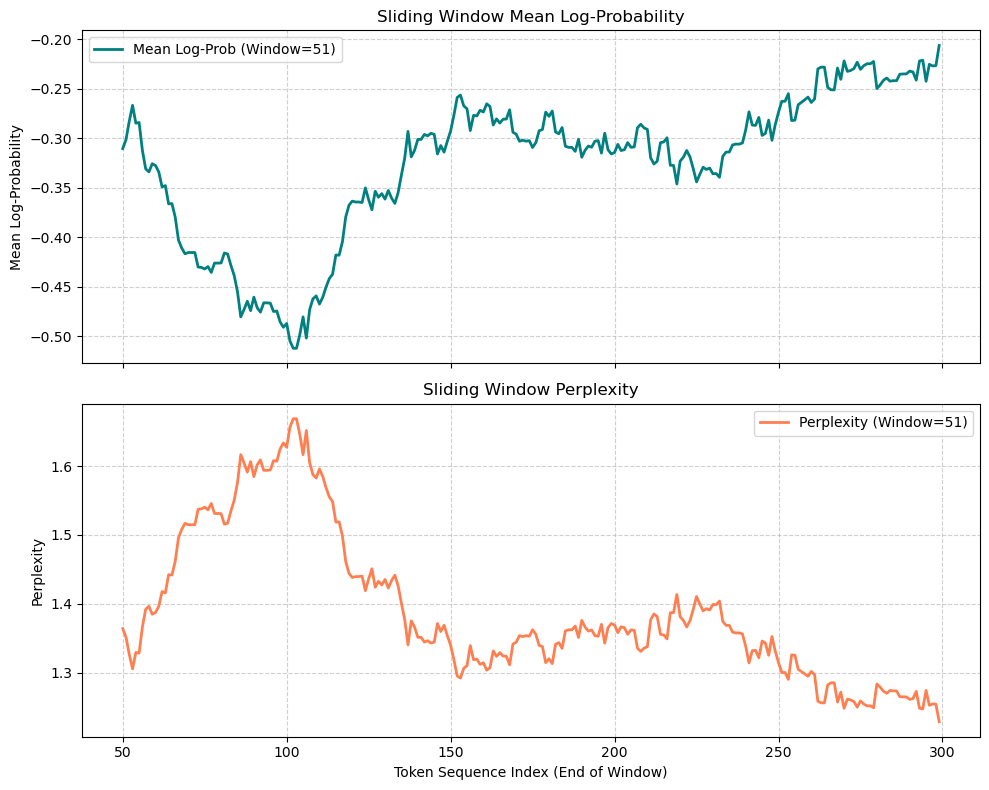

In [285]:
sliding_window = 51
moving_mean_log_probs, sliding_perplexity = plot_sliding_window_metrics(chosen_probs, sliding_window)

In [208]:
probabilities[0,prompt_len+2].cpu().float().numpy()

array([3.4742698e-10, 3.3196557e-11, 1.8474111e-12, ..., 1.4299673e-13,
       1.4299673e-13, 1.4299673e-13], shape=(128256,), dtype=float32)